# Probability & Statistics for Quantitative Finance

## What You'll Learn
1. Probability distributions relevant to finance
2. Moments: mean, variance, skewness, kurtosis
3. Hypothesis testing for trading strategies
4. Bayesian inference fundamentals
5. Maximum Likelihood Estimation
6. Common statistical pitfalls in finance

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm, t, skew, kurtosis
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Key Distributions in Finance

### Normal Distribution
The starting point, but **financial returns are NOT normal**. They exhibit:
- **Fat tails** (excess kurtosis > 0): extreme events happen more often than normal predicts
- **Negative skewness**: large losses are more common than large gains
- **Volatility clustering**: calm periods and volatile periods cluster together

### Student's t-Distribution
Better model for fat tails. With $\nu$ degrees of freedom:
- $\nu \to \infty$: converges to normal
- $\nu \approx 3-5$: typical for daily stock returns

### Log-Normal Distribution
If $\ln(S_T/S_0) \sim N(\mu, \sigma^2)$, then prices $S_T$ are log-normal. This ensures prices can't go negative.

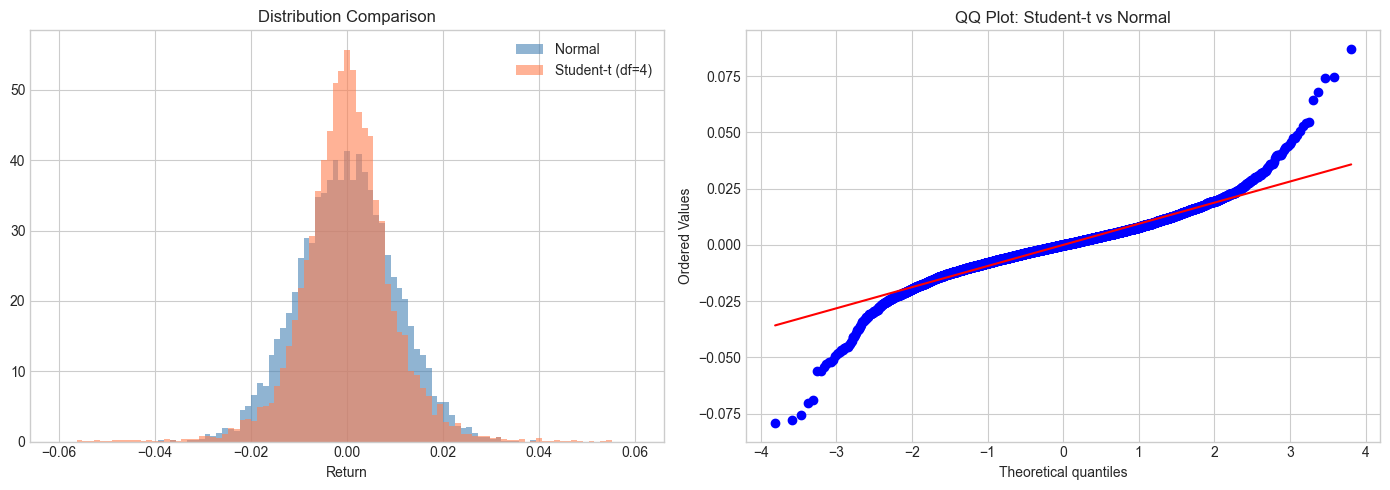

Normal  - Skew: 0.002, Excess Kurtosis: 0.026
t(df=4) - Skew: -0.078, Excess Kurtosis: 6.188


In [2]:
# Simulate returns: Normal vs Student-t vs Actual market-like returns
n = 10000
normal_returns = np.random.normal(0, 0.01, n)
t_returns = stats.t.rvs(df=4, loc=0, scale=0.007, size=n)  # fat-tailed

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram comparison
bins = np.linspace(-0.06, 0.06, 100)
axes[0].hist(normal_returns, bins=bins, density=True, alpha=0.6, label='Normal', color='steelblue')
axes[0].hist(t_returns, bins=bins, density=True, alpha=0.6, label='Student-t (df=4)', color='coral')
axes[0].set_xlabel('Return')
axes[0].set_title('Distribution Comparison')
axes[0].legend()

# QQ plot against normal
stats.probplot(t_returns, dist='norm', plot=axes[1])
axes[1].set_title('QQ Plot: Student-t vs Normal')
plt.tight_layout()
plt.show()

print(f"Normal  - Skew: {skew(normal_returns):.3f}, Excess Kurtosis: {kurtosis(normal_returns):.3f}")
print(f"t(df=4) - Skew: {skew(t_returns):.3f}, Excess Kurtosis: {kurtosis(t_returns):.3f}")

1. 偏度 (Skewness)：分布的“歪不歪”偏度衡量的是分布的对称性。
- 正偏（Positive Skew / Right-skewed）：形状： 尾巴向右侧延伸（拉得很长）。
  - 直观理解： 大部分数据集中在左侧（较小值），但少数极大的“天才”或“黑天鹅”拉高了平均水平。例子： 居民收入（大部分人挣得不多，少数亿万富翁把尾巴拉向右边）。
  - 关系： 均值 > 中位数 > 众数。
- 负偏（Negative Skew / Left-skewed）：形状： 尾巴向左侧延伸。
  - 直观理解： 大部分数据集中在右侧（较大值），但偶尔会出现极小的极端值。例子： 人类的寿命（大部分人活到平均岁数左右，但少数人在很年轻时去世，拉低了左边的尾巴）。
  - 关系： 均值 < 中位数 < 众数。偏度 = 0： 分布左右完美对称（如正态分布）。

2. 峰度 (Kurtosis)：分布的“尖不尖”与“尾巴厚不厚”这是一个经常被误解的概念。
虽然名字叫“峰”度，但它本质上衡量的是极端值（离群点）出现的频率，即分布尾部的厚度。在金融和量化中，我们通常拿它和**正态分布（峰度 = 3）**做比较：
  - 高耸/厚尾 (Leptokurtic, 峰度 > 3)：
    - 形状： 中间特别尖，两边的尾巴比正态分布更厚。
    - 直观理解： 虽然平时波动很小，但一旦出事就是“大事”。
    - 金融意义： 极具风险。这意味着出现金融危机（极端亏损）的概率远高于正态分布的预测。
  - 平阔/瘦尾 (Platykurtic, 峰度 < 3)：形状： 顶部较平坦，尾巴很薄。
    - 直观理解： 数据分布比较均匀，极少出现离群点。
  - 中峰 (Mesokurtic, 峰度 = 3)：
    - 代表： 正态分布。

3. 量化视角下的直观总结为了让你在量化交易里秒懂这两个词，我们可以这样归纳：指标关注点在量化中的“潜台词”偏度 (Skewness)方向性盈利和亏损是对称的吗？（如果是负偏，说明你经常赚小钱，但偶尔亏大钱。）峰度 (Kurtosis)极端性“黑天鹅”出现的概率大吗？（高峰度意味着你不能盲目信任正态分布模型。）

QQ 图的横轴和纵轴分别代表：横轴 (Theoretical Quantiles): 假设数据服从正态分布时，对应的分位数点。纵轴 (Sample Quantiles): 你实际观测到的数据排序后的分位数点。核心逻辑：如果你的数据真的符合正态分布，那么每个实际观测点应该和理论点一一对应，所有的点都会落在一条 $45^{\circ}$ 的直线上。
如何通过 QQ 图看“偏度”和“峰度”？
这是 QQ 图最强大的地方。通过观察点偏离直线的方向，你可以立刻判断数据的分布特征：

A. 厚尾 (Fat Tails / High Kurtosis) —— 量化中最常见的
特征： 点在左侧低于直线，在右侧高于直线（形成一个类似 "S" 的形状，但两端向外拉伸）。

含义： 实际发生的极端亏损和极端盈利的频率，远高于正态分布的预测。这是典型的金融资产特征。

B. 偏度 (Skewness)
左偏 (Negative Skew): 数据点在两端都弯向下方。

右偏 (Positive Skew): 数据点在两端都弯向上方。

## 2. Moments of Return Distributions

| Moment | Formula | Meaning in Finance |
|--------|---------|--------------------|
| Mean ($\mu$) | $E[r]$ | Expected return |
| Variance ($\sigma^2$) | $E[(r-\mu)^2]$ | Risk / volatility squared |
| Skewness | $E\left[\left(\frac{r-\mu}{\sigma}\right)^3\right]$ | Asymmetry of returns |
| Kurtosis | $E\left[\left(\frac{r-\mu}{\sigma}\right)^4\right] - 3$ | Tail heaviness (excess) |

In [3]:
# Generate realistic market returns with fat tails and negative skew
def simulate_market_returns(n=2520, mu=0.0003, sigma=0.01):
    """Simulate returns with GARCH-like volatility clustering."""
    returns = np.zeros(n)
    vol = sigma
    for i in range(n):
        vol = np.sqrt(0.00001 + 0.85 * vol**2 + 0.10 * returns[max(0,i-1)]**2)
        returns[i] = mu + vol * np.random.standard_t(df=5)
    return returns

market_returns = simulate_market_returns()

print("=== Market Return Statistics ===")
print(f"Mean (annualized):     {np.mean(market_returns) * 252 * 100:.2f}%")
print(f"Volatility (annual):   {np.std(market_returns) * np.sqrt(252) * 100:.2f}%")
print(f"Skewness:              {skew(market_returns):.3f}")
print(f"Excess Kurtosis:       {kurtosis(market_returns):.3f}")
print(f"Min daily return:      {market_returns.min()*100:.2f}%")
print(f"Max daily return:      {market_returns.max()*100:.2f}%")

# How often do 3-sigma events occur?
sigma = np.std(market_returns)
three_sigma_events = np.sum(np.abs(market_returns) > 3 * sigma)
expected_normal = n * 2 * (1 - norm.cdf(3))  # expected under normality
print(f"\n3-sigma events: {three_sigma_events} (expected under normal: {expected_normal:.1f})")

=== Market Return Statistics ===
Mean (annualized):     57.86%
Volatility (annual):   149.09%
Skewness:              -0.758
Excess Kurtosis:       28.163
Min daily return:      -135.07%
Max daily return:      92.51%

3-sigma events: 49 (expected under normal: 27.0)


## 3. Hypothesis Testing for Trading Strategies

Before deploying a strategy, you must test: **Is the alpha statistically significant, or just noise?**

### t-test for Mean Return
- $H_0$: Strategy mean return = 0 (no alpha)
- $H_1$: Strategy mean return ≠ 0

$$t = \frac{\bar{r}}{\hat{\sigma}/\sqrt{n}}$$

### Key Concept: Multiple Testing Problem
If you test 100 strategies, ~5 will appear significant at $\alpha = 0.05$ **by chance alone**.
- Use **Bonferroni correction**: $\alpha_{adj} = \alpha / m$
- Or **Benjamini-Hochberg** for FDR control

In [4]:
# Test if a strategy has significant returns
def test_strategy_significance(returns, name="Strategy"):
    """Perform t-test on strategy returns."""
    t_stat, p_value = stats.ttest_1samp(returns, 0)
    sharpe = np.mean(returns) / np.std(returns) * np.sqrt(252)

    print(f"=== {name} ===")
    print(f"Mean daily return:   {np.mean(returns)*100:.4f}%")
    print(f"Daily Sharpe:        {np.mean(returns)/np.std(returns):.4f}")
    print(f"Annualized Sharpe:   {sharpe:.2f}")
    print(f"t-statistic:         {t_stat:.3f}")
    print(f"p-value:             {p_value:.6f}")
    print(f"Significant (5%):    {'YES' if p_value < 0.05 else 'NO'}")
    print()

# Real alpha strategy
alpha_returns = np.random.normal(0.0005, 0.01, 252)  # small but real alpha
test_strategy_significance(alpha_returns, "Real Alpha")

# No alpha (pure noise)
noise_returns = np.random.normal(0, 0.01, 252)
test_strategy_significance(noise_returns, "Noise Strategy")

=== Real Alpha ===
Mean daily return:   0.0330%
Daily Sharpe:        0.0313
Annualized Sharpe:   0.50
t-statistic:         0.495
p-value:             0.620825
Significant (5%):    NO

=== Noise Strategy ===
Mean daily return:   -0.0038%
Daily Sharpe:        -0.0037
Annualized Sharpe:   -0.06
t-statistic:         -0.059
p-value:             0.953283
Significant (5%):    NO



在量化领域，我们经常面临 “多重检验问题” (Multiple Testing Problem)。

如果你测试 100 个随机因子，即使它们全是垃圾，在 $\alpha = 0.05$ 的标准下，统计学上也会有 5 个因子看起来“显著有效”。这就是所谓的 “数据挖掘坑” (Data Mining Bias)。因此，量化研究员通常会：使用更严格的 $\alpha$（如 0.01 甚至更小）。使用 Bonferroni 校正 等方法调整 $\alpha$。

如果没有 $\alpha$，我们就没有评判标准。确定边界： 只有设定了 $\alpha$，我们才能在分布图上划出一块“拒绝域”。如果观测到的数据落在这个区域（对应的 $p$-value $< \alpha$），我们才敢说：“这不可能是巧合，我拒绝原假设。”控制风险： 在量化交易中，犯第一类错误的代价很大。如果你误以为一个烂策略是好策略并投入实盘，你会亏钱。通过调低 $\alpha$（比如调到 0.01），你可以让自己变得更严谨，减少这种误判。

Alpha in finance means excess return above what's expected from the market or a benchmark. It's the "edge" or "skill" a trading strategy has.

A strategy with positive alpha genuinely makes money beyond what randomness or market exposure explains.
A strategy with zero alpha (no alpha) has no real edge — any apparent profit is just luck/noise.
Why test with no alpha in that cell? The code deliberately simulates 200 strategies that have zero true edge (np.random.normal(0, ...) — mean return is exactly 0). The point is to demonstrate the multiple testing problem:

Even when none of the 200 strategies have any skill, ~5% (about 10) will appear statistically significant at the 5% level purely by chance.
This is exactly why backtesting hundreds of ideas without correction leads to overfitting — you pick a strategy that looked great historically but was just a statistical fluke.
In short: the cell proves that if you test enough random noise, some of it will look like signal. That's the danger of data-mining without proper correction (Bonferroni, Benjamini-Hochberg, etc.).

In [5]:
# Multiple testing problem: test 200 random strategies
n_strategies = 200
p_values = []

for i in range(n_strategies):
    fake_returns = np.random.normal(0, 0.01, 252)  # NO alpha
    _, p = stats.ttest_1samp(fake_returns, 0)
    p_values.append(p)

p_values = np.array(p_values)
false_discoveries = np.sum(p_values < 0.05)

print(f"Tested {n_strategies} strategies with ZERO alpha")
print(f"'Significant' at 5%: {false_discoveries} ({false_discoveries/n_strategies*100:.1f}%)")
print(f"Expected false positives: {n_strategies * 0.05:.0f}")
print(f"\n→ This is why backtesting many strategies leads to OVERFITTING!")

# Bonferroni correction
bonferroni_alpha = 0.05 / n_strategies
bonferroni_sig = np.sum(p_values < bonferroni_alpha)
print(f"\nWith Bonferroni correction (α = {bonferroni_alpha:.6f}): {bonferroni_sig} significant")

Tested 200 strategies with ZERO alpha
'Significant' at 5%: 15 (7.5%)
Expected false positives: 10

→ This is why backtesting many strategies leads to OVERFITTING!

With Bonferroni correction (α = 0.000250): 0 significant


## 4. Bayesian Inference

Bayesian approach updates beliefs with data:

$$P(\theta | D) = \frac{P(D|\theta) \cdot P(\theta)}{P(D)}$$

- **Prior** $P(\theta)$: Your belief before seeing data
- **Likelihood** $P(D|\theta)$: Probability of data given parameters
- **Posterior** $P(\theta|D)$: Updated belief

### Why Bayesian in Finance?
- Naturally incorporates uncertainty in parameter estimates
- Regularization through priors (shrinkage towards prior belief)
- Better for small samples (typical in finance)

贝叶斯推断认为：数据是观测到的，参数是随机变量。它最核心的逻辑是：利用新观测到的证据，不断更新你对某个事物的“认知”或“概率”。
所有贝叶斯推断都建立在这个公式之上：$$P(\theta | D) = \frac{P(D | \theta) P(\theta)}{P(D)}$$

- $P(\theta)$ (先验概率, Prior): 在看到新数据之前，你对某个假设（参数 $\theta$）的原始信心。
- $P(D | \theta)$ (似然, Likelihood): 如果你的假设 $\theta$ 是真的，那么观察到当前数据 $D$ 的概率有多大？
- $P(\theta | D)$ (后验概率, Posterior): 结合了新数据后，你对假设 $\theta$ 的最新信心。
- $P(D)$: 归一化常数，确保所有概率加起来等于 1。

你可以把贝叶斯推断想象成一个**“学习机”**：

最初状态： 你有一个最初的猜测（先验）。

获得证据： 你看到了一些新的市场数据或实验结果。

更新认知： 你的猜测会向证据靠拢。如果证据非常强，它会彻底改变你的先验；如果证据很弱，你的认知只会微调。

循环往复： 今天的“后验”就是明天的“先验”。随着数据越来越多，你的认知会越来越接近真相。

Prior:     μ = 0.000000, σ = 0.001000
Data:      μ = 0.000170, σ = 0.001893
Posterior:  μ = 0.000037, σ = 0.000884


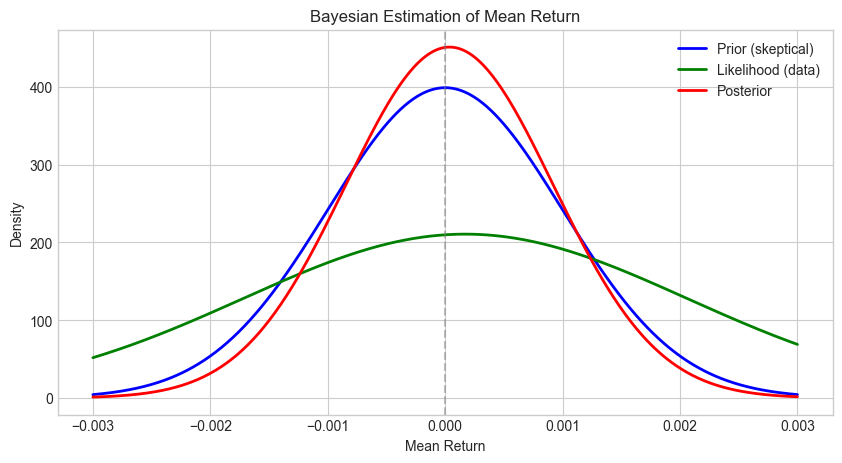


→ Posterior shrinks the data estimate towards the prior (zero)
  This is natural regularization against overfitting!


In [ ]:
# Bayesian estimation of mean return
# We use the "Conjugate prior: Normal-Normal model"
# This means: if both the prior and likelihood are Normal distributions,
# then the posterior is also Normal — giving us a clean closed-form solution.

# ============================================================
# Step 1: Define the PRIOR — our belief BEFORE seeing any data
# ============================================================
# We're skeptical: we believe the true mean return is close to zero.
# mu_prior = 0 means "we expect no alpha by default"
# sigma_prior = 0.001 means "we're fairly confident about this belief"
# (a tighter sigma_prior = stronger conviction in the prior)
mu_prior = 0.0
sigma_prior = 0.001  # tight prior around zero (skeptical)

# ============================================================
# Step 2: Collect OBSERVED DATA (the likelihood)
# ============================================================
# Simulate 60 days of returns with a small true mean of 0.08% per day
observed_returns = np.random.normal(0.0008, 0.015, 60)  # 60 days of data
mu_data = np.mean(observed_returns)                       # sample mean
sigma_data = np.std(observed_returns) / np.sqrt(len(observed_returns))  # standard error of the mean

# ============================================================
# Step 3: POSTERIOR — combine prior + data via conjugate update
# ============================================================
# Key idea: work in "precision" space (precision = 1/variance).
# Precision measures how CERTAIN you are (higher = more certain).
#
# The conjugate update rule is beautifully simple:
#   posterior_precision = prior_precision + data_precision
#   posterior_mean = weighted average of prior and data means,
#                    weighted by their respective precisions.
#
# Intuition: whoever is MORE precise (more certain) gets MORE weight.

precision_prior = 1 / sigma_prior**2      # How certain is our prior?
precision_data = 1 / sigma_data**2         # How certain is our data?
precision_posterior = precision_prior + precision_data  # Combined certainty

# Posterior mean: precision-weighted average of prior mean and data mean
mu_posterior = (precision_prior * mu_prior + precision_data * mu_data) / precision_posterior
# Posterior std: derived from combined precision
sigma_posterior = 1 / np.sqrt(precision_posterior)

print(f"Prior:     μ = {mu_prior:.6f}, σ = {sigma_prior:.6f}")
print(f"Data:      μ = {mu_data:.6f}, σ = {sigma_data:.6f}")
print(f"Posterior: μ = {mu_posterior:.6f}, σ = {sigma_posterior:.6f}")
print(f"\nPrecision weights — Prior: {precision_prior:.0f}, Data: {precision_data:.0f}")
print(f"→ Prior is {'stronger' if precision_prior > precision_data else 'weaker'} than data")

# ============================================================
# Step 4: Visualize how the posterior is a COMPROMISE
# ============================================================
x = np.linspace(-0.003, 0.003, 500)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, norm.pdf(x, mu_prior, sigma_prior), 'b-', linewidth=2, label='Prior (skeptical)')
ax.plot(x, norm.pdf(x, mu_data, sigma_data), 'g-', linewidth=2, label='Likelihood (data)')
ax.plot(x, norm.pdf(x, mu_posterior, sigma_posterior), 'r-', linewidth=2, label='Posterior')
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Mean Return')
ax.set_ylabel('Density')
ax.set_title('Bayesian Estimation of Mean Return')
ax.legend()
plt.show()

# The posterior (red) always sits BETWEEN the prior (blue) and data (green).
# With a tight skeptical prior, the posterior is pulled towards zero,
# even if the data suggests positive returns.
# This is SHRINKAGE — a natural guard against overfitting to noisy data.
print(f"\n→ Posterior shrinks the data estimate towards the prior (zero)")
print(f"  This is natural regularization against overfitting!")

## 5. Maximum Likelihood Estimation (MLE)

Find parameters $\theta$ that maximize:

$$\hat{\theta}_{MLE} = \arg\max_\theta \prod_{i=1}^n f(x_i | \theta)$$

Or equivalently, maximize the log-likelihood:

$$\hat{\theta}_{MLE} = \arg\max_\theta \sum_{i=1}^n \ln f(x_i | \theta)$$

MLE Student-t fit:
  Degrees of freedom: 2.37
  Location (mean):    -0.001068
  Scale:              0.041109


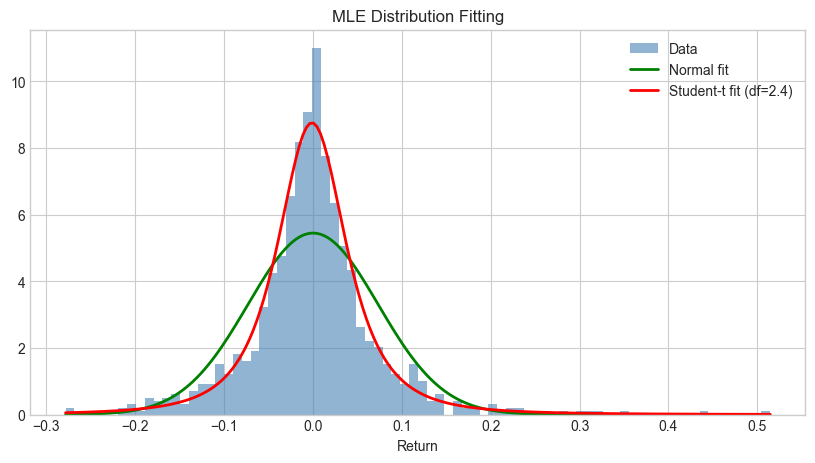

In [7]:
from scipy.optimize import minimize

# Fit Student-t distribution to returns via MLE
returns_sample = simulate_market_returns(1000)

def neg_log_likelihood_t(params, data):
    df, loc, scale = params
    if df <= 2 or scale <= 0:
        return 1e10
    return -np.sum(stats.t.logpdf(data, df=df, loc=loc, scale=scale))

# MLE fit
result = minimize(neg_log_likelihood_t, x0=[5, 0, 0.01], args=(returns_sample,),
                  method='Nelder-Mead')
df_mle, loc_mle, scale_mle = result.x

print(f"MLE Student-t fit:")
print(f"  Degrees of freedom: {df_mle:.2f}")
print(f"  Location (mean):    {loc_mle:.6f}")
print(f"  Scale:              {scale_mle:.6f}")

# Compare fits
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(returns_sample, bins=80, density=True, alpha=0.6, color='steelblue', label='Data')
x = np.linspace(returns_sample.min(), returns_sample.max(), 200)
ax.plot(x, norm.pdf(x, np.mean(returns_sample), np.std(returns_sample)), 'g-',
        linewidth=2, label='Normal fit')
ax.plot(x, stats.t.pdf(x, df=df_mle, loc=loc_mle, scale=scale_mle), 'r-',
        linewidth=2, label=f'Student-t fit (df={df_mle:.1f})')
ax.set_xlabel('Return')
ax.set_title('MLE Distribution Fitting')
ax.legend()
plt.show()

## Exercises

1. **Fat tails**: Download real stock data (or simulate). Calculate excess kurtosis. How does it compare to a normal distribution?
2. **Hypothesis testing**: Generate returns with a known Sharpe ratio of 0.5 annualized. How many days of data do you need for statistical significance at 5%?
3. **Bayesian updating**: Start with a flat prior on a strategy's Sharpe ratio. Update with 30, 90, and 252 days of data. Plot how the posterior tightens.
4. **MLE**: Fit a mixture of two normals to return data. Interpret the two components.
5. **Multiple testing**: Simulate testing 1000 strategies. Apply Bonferroni and Benjamini-Hochberg corrections. Compare results.